# Handle imbalanced dataset: SMOTE

In [1]:
!pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)

   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=5000,
    n_classes=2,
    weights=[0.95, 0.05],
    random_state=42
)

In [4]:
# Lets look at few sample values

print(X[:5]) # has 5 columns/features
print(y[:5])  # target

[[ 0.75867034 -2.63801267 -1.38401797 -0.06648565  0.17849634 -1.34102861
  -1.4866121  -2.1404692  -1.02916584  0.02224388 -0.65326801 -0.44023359
   1.78855929 -0.95342459  1.41149121 -1.84906845 -1.35731792  1.1759368
  -0.41890189  2.71696652]
 [ 1.18222323 -3.94000838 -1.39611463 -0.62634799 -1.1247389  -0.43586774
   1.32249646  0.0424581   0.54042193 -0.90969569 -0.95296379 -0.46147062
   1.68516253  1.19169424  1.06059264 -1.90937053  0.59056744  2.20340867
  -0.04280561  2.66927114]
 [-1.70462196  0.76543749  0.94563343  1.54484146  0.82342318  0.24549868
  -0.71480726 -0.25518717  1.4777203   0.06479135 -0.08313353 -0.4030854
  -1.05916271 -0.54129909  0.60409743 -1.28217767  1.3610067   0.50436507
   1.79452485 -0.05391428]
 [ 1.20346006 -0.87813507 -0.13897273 -0.33920477 -1.02731342  0.92652018
   1.18689308  0.95264934  1.82058027  0.62125609  0.53413594 -0.73051169
  -2.25640005  0.41507251  0.29196586 -2.27236658  0.4456435  -1.6510534
   1.34518466 -0.4152031 ]
 [ 1.54

In [9]:
# Check how many class 0 and class 1

from collections import Counter
 
print(Counter(y))

Counter({np.int64(0): 4724, np.int64(1): 276})


In [10]:
# percentage of class 1

276 / (4724 + 276)

0.0552

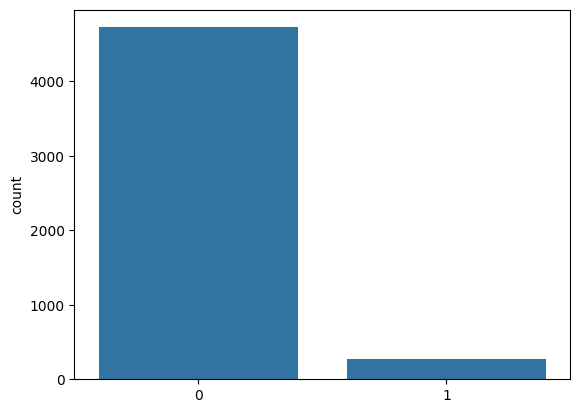

In [15]:
# lets plot y

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y)
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step1) Train Normal Model

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98       944
           1       0.67      0.55      0.61        56

    accuracy                           0.96      1000
   macro avg       0.82      0.77      0.79      1000
weighted avg       0.96      0.96      0.96      1000



### Observation: Poor recall for minority class 1.

# Step2) Apply SMOTE

In [13]:
from imblearn.over_sampling import SMOTE

sm = SMOTE()
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Step 3) Train Again

In [14]:
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.96      0.97       944
           1       0.55      0.75      0.63        56

    accuracy                           0.95      1000
   macro avg       0.77      0.86      0.80      1000
weighted avg       0.96      0.95      0.95      1000



### Observation: Shows improvement in recall for minority class 1